In [1]:
import torch
import requests
import matplotlib.pyplot as plt
from PIL import Image

from transformers import (
    AutoProcessor,
    PaliGemmaForConditionalGeneration,
    PaliGemmaProcessor
)

/home/ein/miniconda3/envs/deepl/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

#### Model loading

In [3]:
MODEL_ID = "google/paligemma2-3b-mix-224"

In [4]:
model = PaliGemmaForConditionalGeneration.from_pretrained(
    MODEL_ID,
    device_map="auto",
    attn_implementation="sdpa"
).to(device)
processor = AutoProcessor.from_pretrained(
    MODEL_ID,
)

# processor = PaliGemmaProcessor.from_pretrained(
#     "google/paligemma2-3b-mix-224",
# )

Loading weights: 100%|██████████| 727/727 [00:39<00:00, 18.36it/s]


In [5]:
prompt = "<image> What is in this image?"
url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/pipeline-cat-chonk.jpeg"
image = Image.open(requests.get(url, stream=True).raw)
inputs = processor(text=prompt, images=image, return_tensors="pt").to(model.device)

In [6]:
# # 2. fix static cache crash: drop cache_implementation, HybridCache auto-selected
# inputs = inputs.pop("labels", None) # processor returns training `labels`, filtered in generate but safe to drop


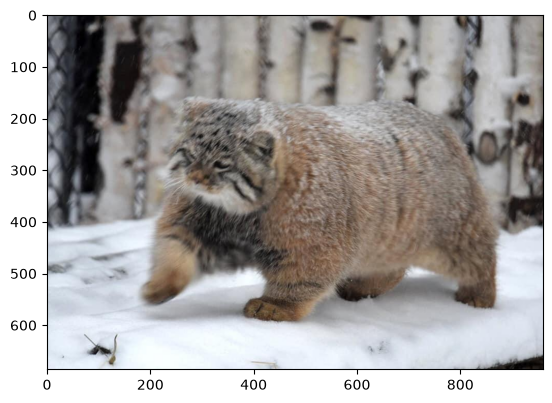

In [7]:
plt.imshow(image)

In [8]:
print(inputs)

{'input_ids': tensor([[257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152,
         257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152,
         257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152,
         257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152,
         257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152,
         257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152,
         257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152,
         257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152,
         257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152,
         257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152,
         257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152,
         257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152, 257152,
         25715

In [9]:
# cache_implementation didn't work
# output = model.generate(**inputs, max_new_tokens=50, cache_implementation="static")   
output = model.generate(**inputs, max_new_tokens=100, do_sample=False)
print(processor.decode(output[0], skip_special_tokens=True))

 What is in this image?
In this image we can see an animal on the snow. In the background there are trees and a fence.


#### Model-Adjustment and Fine-tuning

In [10]:
model = PaliGemmaForConditionalGeneration.from_pretrained(
    MODEL_ID, torch_dtype=torch.bfloat16).to(device)

print("Model loaded on device:", device)
print("--- Model Summary ---")
print(model)

Loading weights: 100%|██████████| 727/727 [00:00<00:00, 11005.89it/s]


Model loaded on device: cuda
--- Model Summary ---
PaliGemmaForConditionalGeneration(
  (model): PaliGemmaModel(
    (vision_tower): SiglipVisionModel(
      (embeddings): SiglipVisionEmbeddings(
        (patch_embedding): Conv2d(3, 1152, kernel_size=(14, 14), stride=(14, 14), padding=valid)
        (position_embedding): Embedding(256, 1152)
      )
      (encoder): SiglipEncoder(
        (layers): ModuleList(
          (0-26): 27 x SiglipEncoderLayer(
            (layer_norm1): LayerNorm((1152,), eps=1e-06, elementwise_affine=True, bias=True)
            (self_attn): SiglipAttention(
              (k_proj): Linear(in_features=1152, out_features=1152, bias=True)
              (v_proj): Linear(in_features=1152, out_features=1152, bias=True)
              (q_proj): Linear(in_features=1152, out_features=1152, bias=True)
              (out_proj): Linear(in_features=1152, out_features=1152, bias=True)
            )
            (layer_norm2): LayerNorm((1152,), eps=1e-06, elementwise_affine=

In [11]:
# -- Freeze model layers to avoid training them
for param in model.base_model.vision_tower.parameters():
    param.requires_grad = False

for param in model.base_model.multi_modal_projector.parameters():
    param.requires_grad = False
print("Done setting static layers")

Done setting static layers


In [15]:
# Set the custom action dimension
num_actions = 128  # replace with your action vocabulary size

# Replace the final language-model head
if hasattr(model, "language_model") and hasattr(model.language_model, "lm_head"):
    old_head = model.language_model.lm_head
    model.language_model.lm_head = torch.nn.Linear(
        old_head.in_features,
        num_actions,
        bias=False
    )
    model.language_model.config.vocab_size = num_actions
elif hasattr(model, "lm_head"):
    old_head = model.lm_head
    model.lm_head = torch.nn.Linear(
        old_head.in_features,
        num_actions,
        bias=False
    )
    model.config.vocab_size = num_actions
else:
    raise AttributeError("No LM head found on this model.")

# Keep config consistent for generation / downstream use
model.config.vocab_size = num_actions

# Optional: freeze all layers and train only the new output head
for p in model.parameters():
    p.requires_grad = False
if hasattr(model, "language_model") and hasattr(model.language_model, "lm_head"):
    for p in model.language_model.lm_head.parameters():
        p.requires_grad = True
elif hasattr(model, "lm_head"):
    for p in model.lm_head.parameters():
        p.requires_grad = True

print(f"Updated final layer to output {num_actions} action logits.")
print(f"Trainable parameters now: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

Updated final layer to output 128 action logits.
Trainable parameters now: 294912


In [16]:
print(model)

PaliGemmaForConditionalGeneration(
  (model): PaliGemmaModel(
    (vision_tower): SiglipVisionModel(
      (embeddings): SiglipVisionEmbeddings(
        (patch_embedding): Conv2d(3, 1152, kernel_size=(14, 14), stride=(14, 14), padding=valid)
        (position_embedding): Embedding(256, 1152)
      )
      (encoder): SiglipEncoder(
        (layers): ModuleList(
          (0-26): 27 x SiglipEncoderLayer(
            (layer_norm1): LayerNorm((1152,), eps=1e-06, elementwise_affine=True, bias=True)
            (self_attn): SiglipAttention(
              (k_proj): Linear(in_features=1152, out_features=1152, bias=True)
              (v_proj): Linear(in_features=1152, out_features=1152, bias=True)
              (q_proj): Linear(in_features=1152, out_features=1152, bias=True)
              (out_proj): Linear(in_features=1152, out_features=1152, bias=True)
            )
            (layer_norm2): LayerNorm((1152,), eps=1e-06, elementwise_affine=True, bias=True)
            (mlp): SiglipMLP(
    

In [17]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print(f"Trainable parameters: {trainable_params:,}")
print(f"Total parameters: {total_params:,}")
print(f"Trainable ratio: {100 * trainable_params / total_params:.6f}%")

Trainable parameters: 294,912
Total parameters: 3,032,537,328
Trainable ratio: 0.009725%


In [18]:
# Print trainable parts of the model
print("Trainable parameter groups:")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"- {name}: shape={tuple(param.shape)}, params={param.numel():,}")

# Optional quick summary (uses existing notebook variables)
print(f"\nTotal trainable params: {trainable_params:,} / {total_params:,}")
print(f"Trainable ratio: {100 * trainable_params / total_params:.6f}%")

Trainable parameter groups:
- lm_head.weight: shape=(128, 2304), params=294,912

Total trainable params: 294,912 / 3,032,537,328
Trainable ratio: 0.009725%
